# Data Loading

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/combined_clean.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,title,score,members,favorites,episodes,status,genres,season,year
0,Jujutsu Kaisen,8.51,2983273,95527,24,Finished Airing,"['Action', 'Award Winning', 'Supernatural']",fall,2020
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,1756871,13487,1,Finished Airing,"['Action', 'Supernatural']",fall,2020
2,Haikyuu!! To the Top Part 2,8.56,918587,6479,12,Finished Airing,['Sports'],fall,2020
3,Tonikaku Kawaii,7.84,829699,10466,12,Finished Airing,"['Comedy', 'Romance']",fall,2020
4,Dungeon ni Deai wo Motomeru no wa Machigatteir...,7.46,674005,1966,12,Finished Airing,"['Action', 'Adventure', 'Fantasy']",fall,2020


# Data Preprocessing & Normalization

In [ ]:
# Normalize members
df['members_norm'] = (df['members'] - df['members'].min()) / (df['members'].max() - df['members'].min())

# Normalize favorites
df['favorites_norm'] = (df['favorites'] - df['favorites'].min()) / (df['favorites'].max() - df['favorites'].min())

df[['members','members_norm','favorites','favorites_norm']].head()

,members,members_norm,favorites,favorites_norm
0,2983273,1.000000,95527,1.000000
1,1756871,0.580293,13487,0.140663
2,918587,0.293409,6479,0.067257
3,829699,0.262990,10466,0.109020
4,674005,0.209707,1966,0.019986


# Weighted Ranking System (WRS)

In [ ]:
df['final_score'] = (
    0.6 * df['score'] +
    0.25 * df['members_norm'] +
    0.15 * df['favorites_norm']
)

df[['title','score','members_norm','favorites_norm','final_score']].head()

,title,score,members_norm,favorites_norm,final_score
0,Jujutsu Kaisen,8.51,1.000000,1.000000,5.506000
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,0.580293,0.140663,5.290173
2,Haikyuu!! To the Top Part 2,8.56,0.293409,0.067257,5.219441
3,Tonikaku Kawaii,7.84,0.262990,0.109020,4.786100
4,Dungeon ni Deai wo Motomeru no wa Machigatteir...,7.46,0.209707,0.019986,4.531425


# Top 10 Ranking Results

In [ ]:
df_sorted = df.sort_values(by='final_score', ascending=False)

top_10 = df_sorted.head(10)

top_10[['title','score','members','favorites','final_score']]

,title,score,members,favorites,final_score
75,Sousou no Frieren,9.28,1354878,86012,5.813730
400,Shingeki no Kyojin: The Final Season,8.78,2260937,53905,5.540803
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,1094783,33046,5.516258
0,Jujutsu Kaisen,8.51,2983273,95527,5.506000
57,Bleach: Sennen Kessen-hen,8.98,690298,23064,5.477968
424,Gintama: The Final,9.05,180884,4637,5.447431
157,Fruits Basket: The Final,8.94,556503,21277,5.439713
426,Shingeki no Kyojin: The Final Season Part 2,8.77,1535035,32219,5.438625
114,One Piece Fan Letter,9.02,146654,2543,5.423213
76,Kusuriya no Hitorigoto,8.85,805604,27072,5.416130


# Hidden Gem Detection

In [ ]:
rating_threshold = 8.0
popularity_threshold = df['members'].quantile(0.3)

hidden_gems = df[
    (df['score'] >= rating_threshold) &
    (df['members'] <= popularity_threshold)
]

hidden_gems = hidden_gems.sort_values(by='score', ascending=False)

top_hidden_gems = hidden_gems.head(10)

top_hidden_gems[['title','score','members']]

,title,score,members
424,Gintama: The Final,9.05,180884
114,One Piece Fan Letter,9.02,146654
142,Kingdom 3rd Season,8.84,131593
374,Monogatari Series: Off & Monster Season,8.65,100817
344,Shiguang Dailiren II,8.64,168317
370,Kimi ni Todoke 3rd Season,8.43,110092
20,Golden Kamuy 3rd Season,8.43,197662
22,Tian Guan Cifu,8.42,174991
446,Fruits Basket: Prelude,8.36,129304
249,Girls Band Cry,8.36,132995


# Visualization

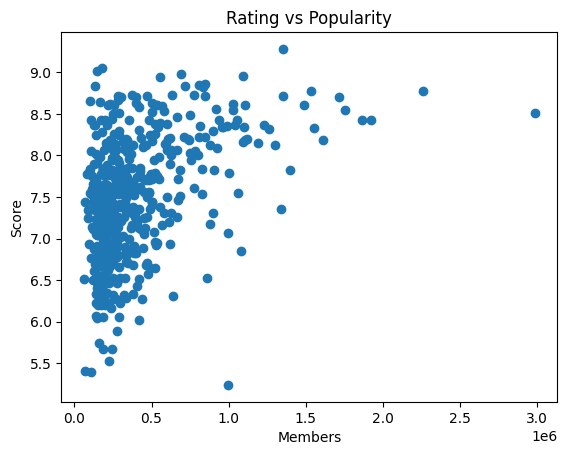

<Figure size 640x480 with 0 Axes>

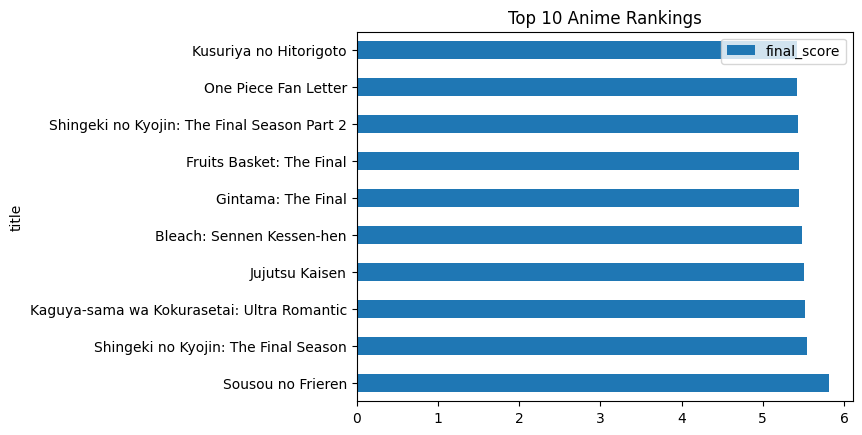

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: Rating vs Popularity
plt.figure()
plt.scatter(df['members'], df['score'])
plt.xlabel("Members")
plt.ylabel("Score")
plt.title("Rating vs Popularity")
plt.show()

# Top 10 bar chart
plt.figure()
top_10.plot(x='title', y='final_score', kind='barh')
plt.title("Top 10 Anime Rankings")
plt.show()

In [ ]:
import os

# Create outputs folder if not exists
os.makedirs("outputs", exist_ok=True)

# Save files
top_10.to_csv("outputs/top10_anime.csv", index=False)
top_hidden_gems.to_csv("outputs/hidden_gems.csv", index=False)